# Parrot Bebop 2 — UAV Flight Data Analysis

**4-Pillar Analysis Pipeline**

| Pillar | Description |
|--------|-------------|
| **1 — Time Series** | Accelerometer & Gyroscope visualisation across fault conditions |
| **2 — Pre-processing & Feature Extraction** | Bandpass filtering, windowed statistics, PSD |
| **3 — Classification** | Random Forest + SVM to predict propeller fault type |
| **4 — Anomaly Detection** | Isolation Forest, Z-score, reconstruction error, ROC curves |

---
**Dataset:** 20 normalised CSV files · 86 016 rows × 24 channels · 500 Hz · Parrot Bebop 2  
**Fault labels (per propeller):** `0` Healthy · `1` Chipped edge · `2` Bent tip  
**Note:** Barometer channels are **not** present in the normalised dataset — only accelerometer and gyroscope data are available.

## Part 0 — Setup

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import signal as sp_signal
from scipy.stats import skew as sp_skew, kurtosis as sp_kurtosis, spearmanr
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score, roc_curve, auc
)

warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid', palette='tab10', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.facecolor': 'white',
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'legend.fontsize': 9
})

# ── Constants ──────────────────────────────────────────────────────────────
DATA_DIR    = Path('./UAV_measurement_data/Parrot_Bebop_2/Normalized_data')
SAMPLE_RATE = 500          # Hz
WINDOW_SIZE = 500          # samples = 1 second per window
PROPELLERS  = list('ABCD')
FAULT_MAP   = {0: 'Healthy', 1: 'Chipped', 2: 'Bent'}
COLORS      = {'Healthy': '#2196F3', 'Chipped': '#FF9800', 'Bent': '#F44336'}

print('Libraries loaded successfully.')
print(f'Data directory : {DATA_DIR.resolve()}')
print(f'Sample rate    : {SAMPLE_RATE} Hz  |  Window : {WINDOW_SIZE} samples = {WINDOW_SIZE/SAMPLE_RATE:.1f} s')

Libraries loaded successfully.
Data directory : C:\Users\roni4\Desktop\Python\UAV-THESIS\UAV-THESIS-FINAL\UAV_measurement_data\Parrot_Bebop_2\Normalized_data
Sample rate    : 500 Hz  |  Window : 500 samples = 1.0 s


In [ ]:
# ── File pattern and column helpers ───────────────────────────────────────
PATTERN = re.compile(
    r'Bebop2_(\d+g)_(\d+kdps)_normalized_(\d{4})\.csv',
    re.IGNORECASE
)

def accel_cols(prop):
    p = prop.lower()
    return [f'{p}_ax', f'{p}_ay', f'{p}_az']

def gyro_cols(prop):
    p = prop.lower()
    return [f'{p}_gx', f'{p}_gy', f'{p}_gz']

def imu_cols(prop):
    return accel_cols(prop) + gyro_cols(prop)

def load_file(path):
    m = PATTERN.match(path.name)
    if not m:
        return None
    label_str = m.group(3)
    df = pd.read_csv(path)
    df.columns = df.columns.str.lower()
    df['time_s'] = df.index / SAMPLE_RATE
    df['label']  = label_str
    for i, p in enumerate(list('abcd')):
        fault_val = int(label_str[i])
        df[f'{p}_fault']       = fault_val
        df[f'{p}_fault_label'] = FAULT_MAP[fault_val]
    return df

# ── Batch load ─────────────────────────────────────────────────────────────
csv_files = sorted(DATA_DIR.glob('*.csv'))
frames = {}
for f in csv_files:
    df = load_file(f)
    if df is not None:
        frames[df['label'].iloc[0]] = df

print(f'Loaded {len(frames)} files  |  {sum(len(v) for v in frames.values()):,} total rows\n')

hdr = f"{'Label':<8}  {'Prop A':>10}  {'Prop B':>10}  {'Prop C':>10}  {'Prop D':>10}"
print(hdr)
print('-' * len(hdr))
for lbl in sorted(frames):
    faults = [FAULT_MAP[int(lbl[i])] for i in range(4)]
    print(f'{lbl:<8}  {faults[0]:>10}  {faults[1]:>10}  {faults[2]:>10}  {faults[3]:>10}')

## Part 1 — Time Series Analysis

### §1.1 Dataset Overview

In [ ]:
overview_rows = []
for lbl in sorted(frames):
    df_ = frames[lbl]
    overview_rows.append({
        'File': f'...normalized_{lbl}.csv',
        'Label': lbl,
        'Prop A': FAULT_MAP[int(lbl[0])],
        'Prop B': FAULT_MAP[int(lbl[1])],
        'Prop C': FAULT_MAP[int(lbl[2])],
        'Prop D': FAULT_MAP[int(lbl[3])],
        'Rows': len(df_),
        'Duration (s)': f'{len(df_)/SAMPLE_RATE:.0f}'
    })

ov_df = pd.DataFrame(overview_rows)
print('DATASET OVERVIEW')
print('=' * 80)
print(ov_df.to_string(index=False))
print('\n' + '=' * 80)
print('NOTE: Barometer channels (bar_H, bar_L, bar_X) are NOT in the normalised data.')
print('      24 channels available: Accel (X/Y/Z) + Gyro (X/Y/Z) per propeller A-D.')
print('=' * 80)
print('\nHealthy flight (0000) — Propeller A quick statistics:')
display(frames['0000'][accel_cols('A') + gyro_cols('A')].describe().round(5))

DATASET OVERVIEW
                  File Label  Prop A  Prop B  Prop C  Prop D  Rows Duration (s)
...normalized_0000.csv  0000 Healthy Healthy Healthy Healthy 86016          172
...normalized_0001.csv  0001 Healthy Healthy Healthy Chipped 86016          172
...normalized_0002.csv  0002 Healthy Healthy Healthy    Bent 86016          172
...normalized_0010.csv  0010 Healthy Healthy Chipped Healthy 86016          172
...normalized_0020.csv  0020 Healthy Healthy    Bent Healthy 86016          172
...normalized_0022.csv  0022 Healthy Healthy    Bent    Bent 86016          172
...normalized_0100.csv  0100 Healthy Chipped Healthy Healthy 86016          172
...normalized_0102.csv  0102 Healthy Chipped Healthy    Bent 86016          172
...normalized_0120.csv  0120 Healthy Chipped    Bent Healthy 86016          172
...normalized_0122.csv  0122 Healthy Chipped    Bent    Bent 86016          172
...normalized_0200.csv  0200 Healthy    Bent Healthy Healthy 86016          172
...normalized_1000.csv 

,a_ax,a_ay,a_az,a_gx,a_gy,a_gz
count,86016.00000,86016.00000,86016.00000,86016.00000,86016.00000,86016.00000
mean,-0.37749,0.01505,0.05987,-0.00045,0.00189,0.00131
std,0.17517,0.12778,0.05387,0.05814,0.02311,0.03483
min,-0.77758,-1.00000,-0.30919,-0.56680,-0.10884,-0.26760
25%,-0.49639,-0.05312,0.02434,-0.03371,-0.01324,-0.02251
50%,-0.41445,0.02492,0.05928,-0.00047,0.00188,0.00139
75%,-0.30980,0.09105,0.09407,0.03288,0.01717,0.02507
max,0.18535,1.00000,0.36812,0.54702,0.11351,0.27568


### §1.2 Accelerometer Time Series — Healthy Flight

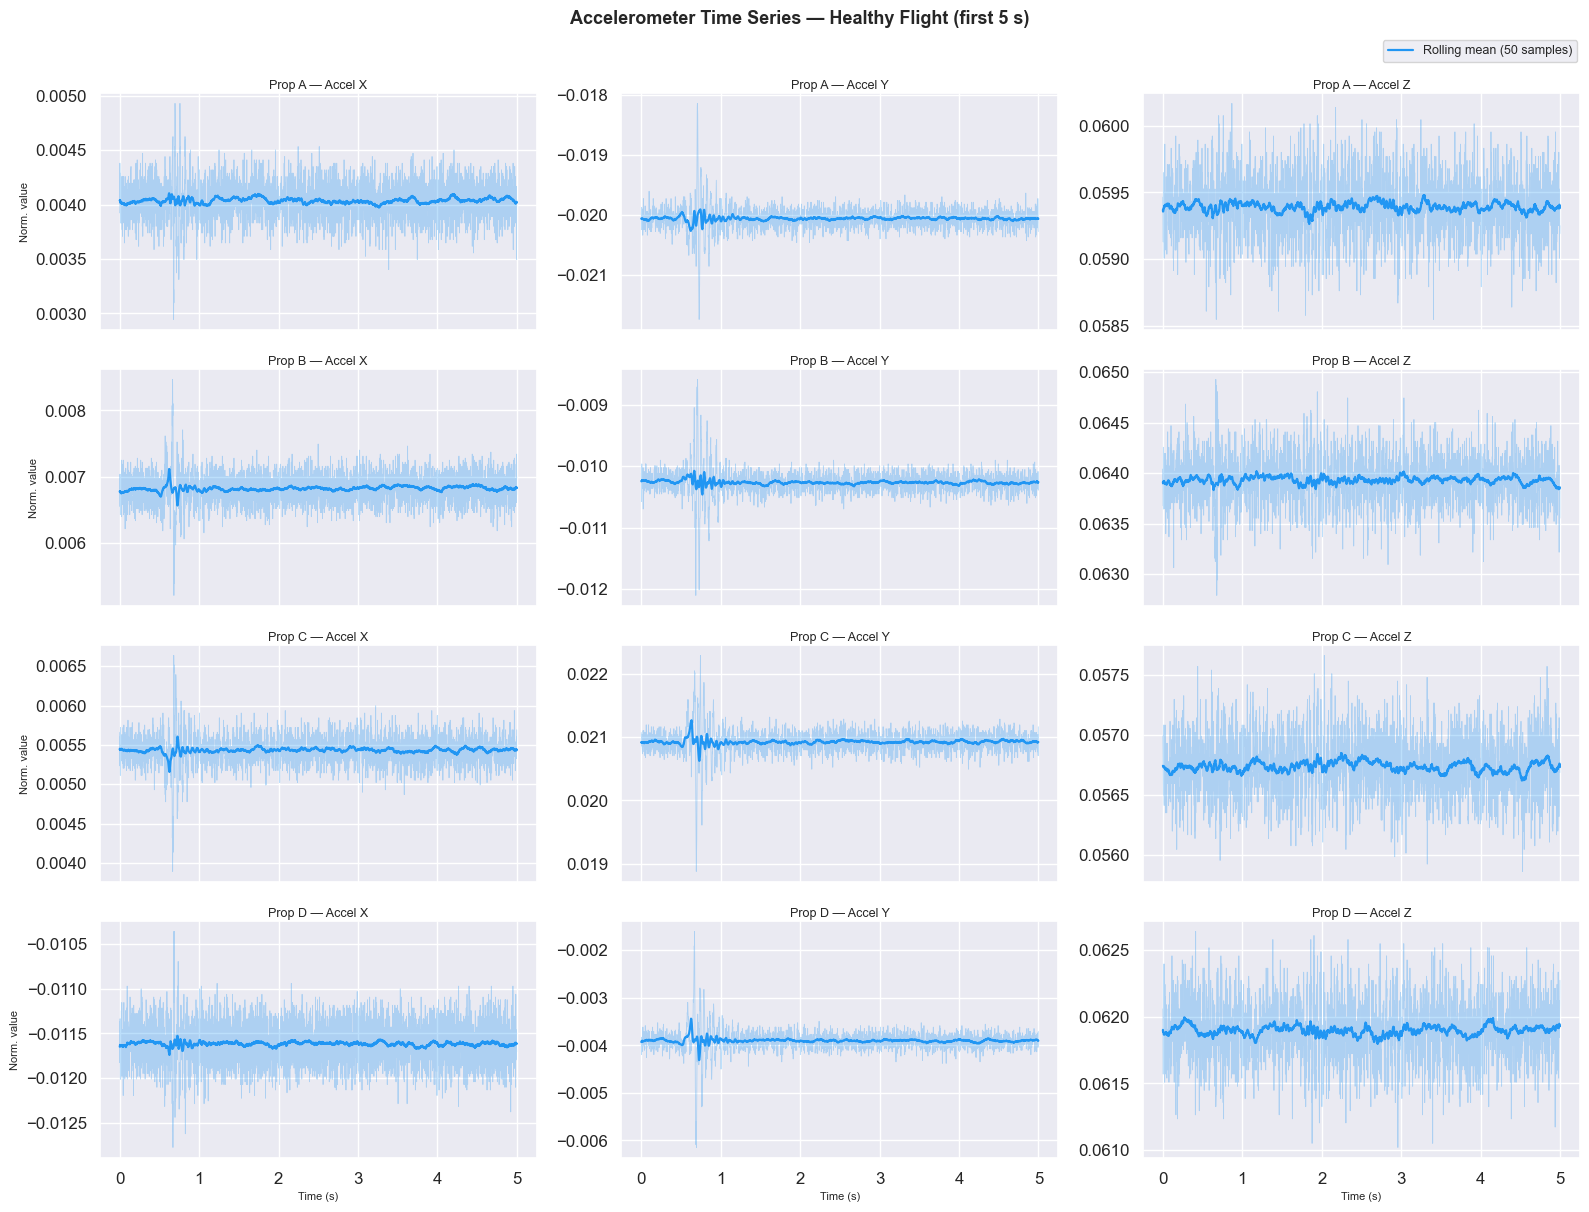

In [ ]:
N_PLOT    = 2500   # 5 seconds
AX_LABELS = ['X', 'Y', 'Z']
df_h      = frames['0000']

fig, axes = plt.subplots(4, 3, figsize=(16, 12), sharex=True)

for r, prop in enumerate(PROPELLERS):
    for c, (col, ax_lbl) in enumerate(zip(accel_cols(prop), AX_LABELS)):
        ax = axes[r, c]
        t  = df_h['time_s'].iloc[:N_PLOT]
        y  = df_h[col].iloc[:N_PLOT]
        ax.plot(t, y, color=COLORS['Healthy'], alpha=0.30, lw=0.6)
        ax.plot(t, y.rolling(50, center=True, min_periods=1).mean(),
                color=COLORS['Healthy'], lw=1.6)
        ax.set_title(f'Prop {prop} — Accel {ax_lbl}', fontsize=9, pad=3)
        if c == 0:
            ax.set_ylabel('Norm. value', fontsize=8)
        if r == 3:
            ax.set_xlabel('Time (s)', fontsize=8)

leg_line = plt.Line2D([0], [0], color=COLORS['Healthy'], lw=1.6, label='Rolling mean (50 samples)')
fig.legend(handles=[leg_line], loc='upper right', fontsize=9, bbox_to_anchor=(0.99, 0.99))
fig.suptitle('Accelerometer Time Series — Healthy Flight (first 5 s)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_1_2_accel_timeseries.png', bbox_inches='tight', dpi=100)
plt.show()

### §1.3 Gyroscope Time Series — Healthy Flight

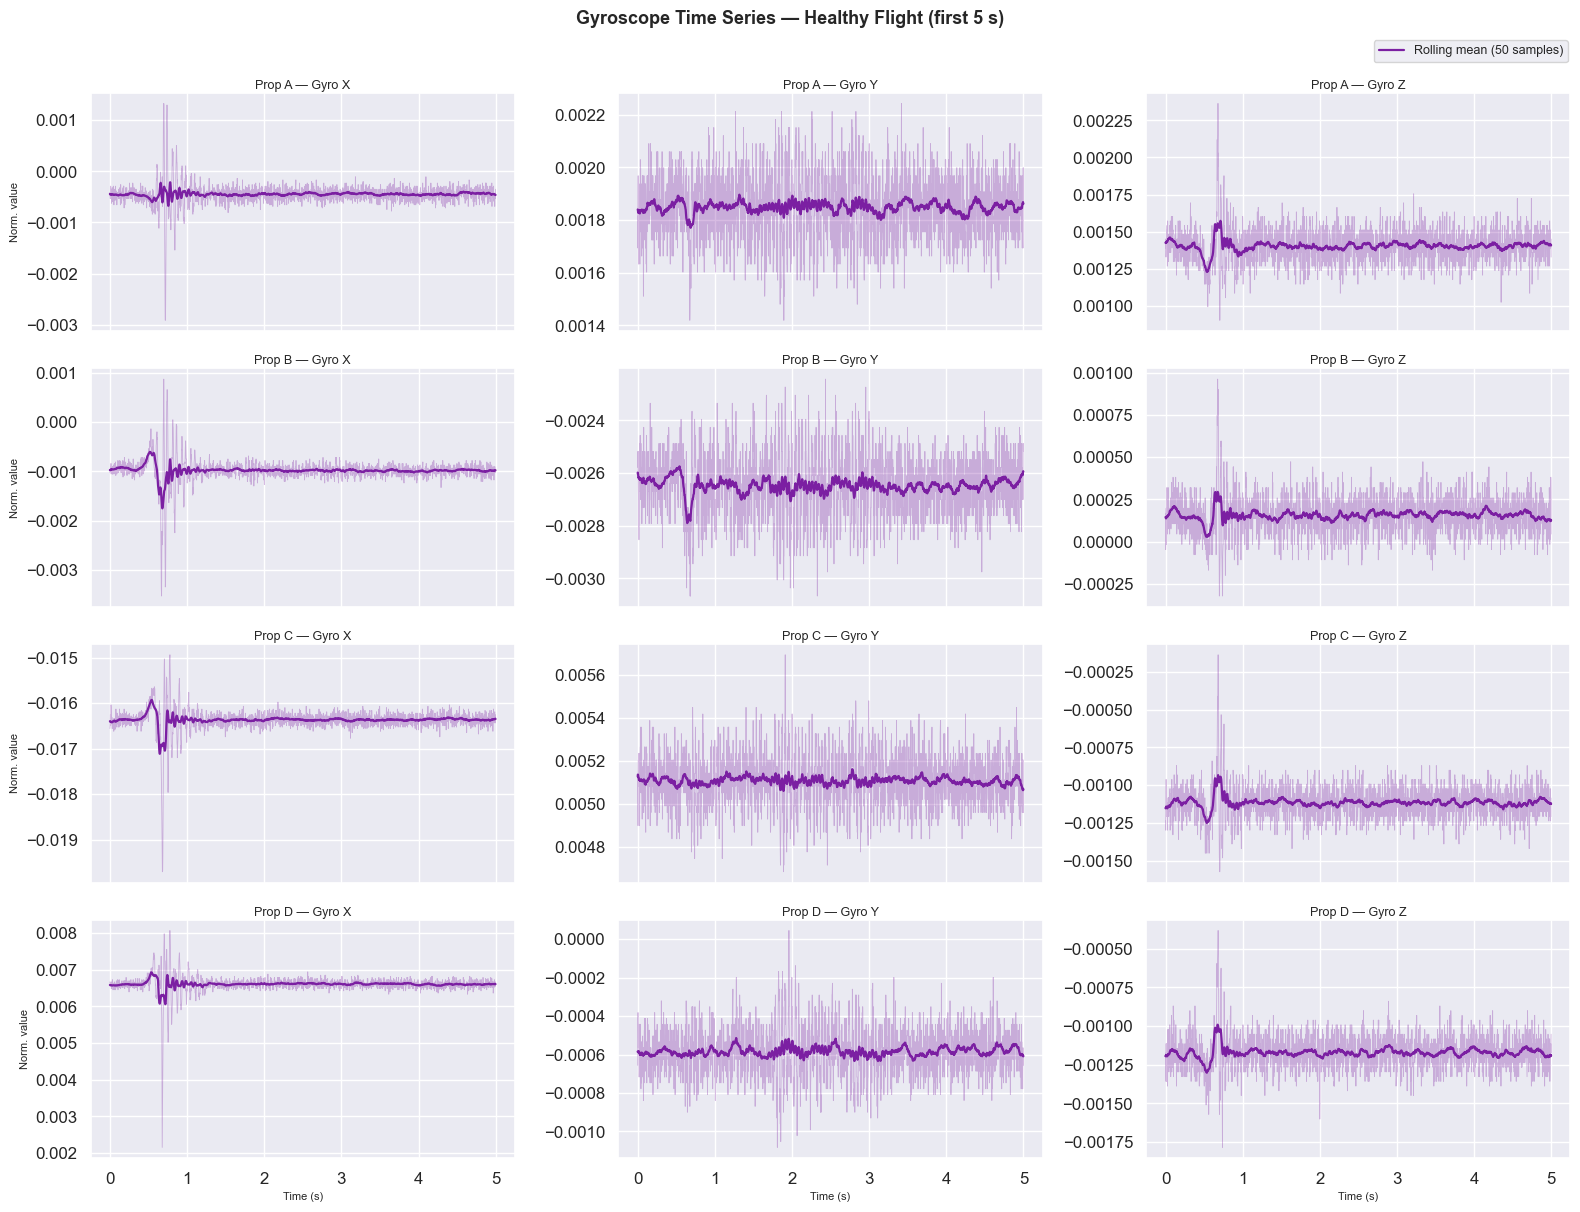

In [ ]:
GY_COLOR = '#7B1FA2'

fig, axes = plt.subplots(4, 3, figsize=(16, 12), sharex=True)

for r, prop in enumerate(PROPELLERS):
    for c, (col, ax_lbl) in enumerate(zip(gyro_cols(prop), AX_LABELS)):
        ax = axes[r, c]
        t  = df_h['time_s'].iloc[:N_PLOT]
        y  = df_h[col].iloc[:N_PLOT]
        ax.plot(t, y, color=GY_COLOR, alpha=0.30, lw=0.6)
        ax.plot(t, y.rolling(50, center=True, min_periods=1).mean(),
                color=GY_COLOR, lw=1.6)
        ax.set_title(f'Prop {prop} — Gyro {ax_lbl}', fontsize=9, pad=3)
        if c == 0:
            ax.set_ylabel('Norm. value', fontsize=8)
        if r == 3:
            ax.set_xlabel('Time (s)', fontsize=8)

leg_line = plt.Line2D([0], [0], color=GY_COLOR, lw=1.6, label='Rolling mean (50 samples)')
fig.legend(handles=[leg_line], loc='upper right', fontsize=9, bbox_to_anchor=(0.99, 0.99))
fig.suptitle('Gyroscope Time Series — Healthy Flight (first 5 s)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_1_3_gyro_timeseries.png', bbox_inches='tight', dpi=100)
plt.show()

### §1.4 Fault Overlay — Accelerometer

For each propeller, overlay the signal from the three conditions: Healthy / Chipped edge / Bent tip,  
using files where only that single propeller is faulted.

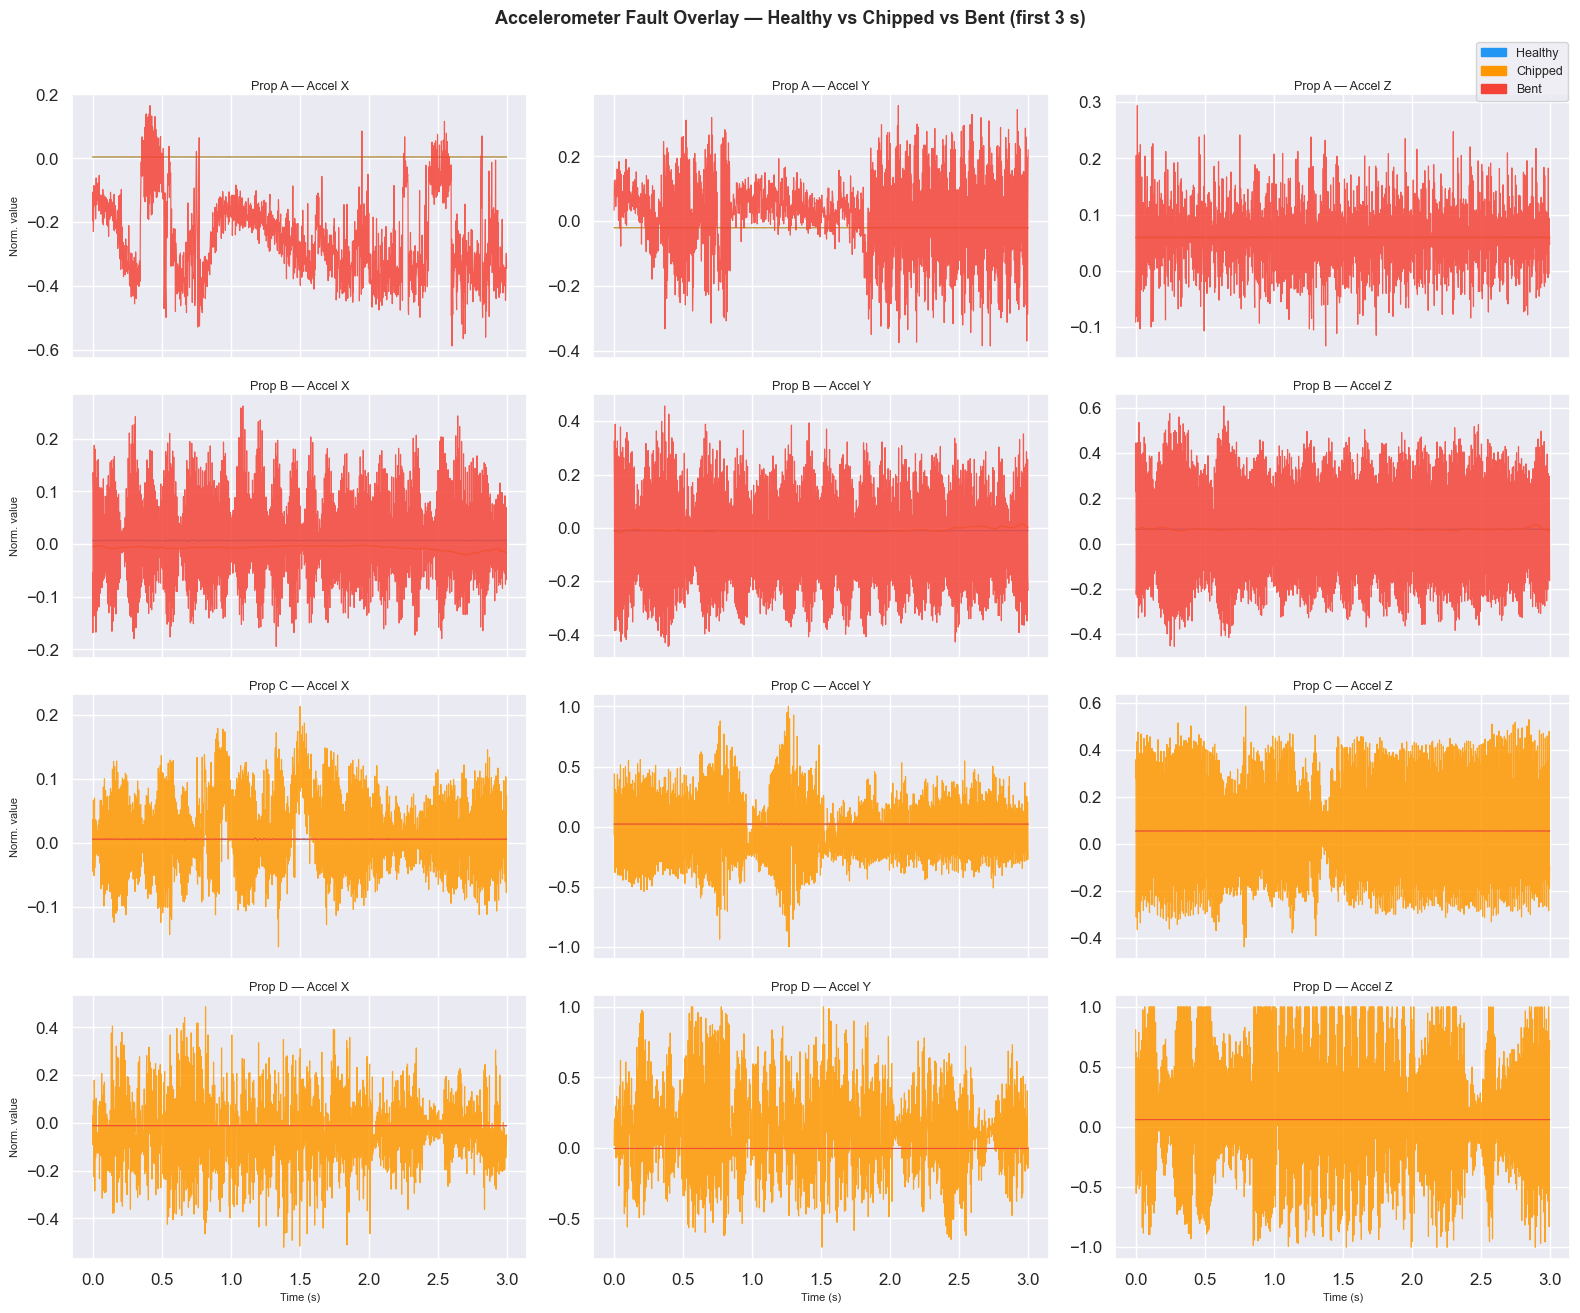

In [ ]:
# Files where only one propeller is faulted
SINGLE_FAULT = {
    'A': {'Healthy': '0000', 'Chipped': '1000', 'Bent': '2000'},
    'B': {'Healthy': '0000', 'Chipped': '0100', 'Bent': '0200'},
    'C': {'Healthy': '0000', 'Chipped': '0010', 'Bent': '0020'},
    'D': {'Healthy': '0000', 'Chipped': '0001', 'Bent': '0002'},
}
N_PLOT2 = 1500   # 3 seconds — cleaner overlay

fig, axes = plt.subplots(4, 3, figsize=(16, 13), sharex=True)

for r, prop in enumerate(PROPELLERS):
    file_map = SINGLE_FAULT[prop]
    for c, (col, ax_lbl) in enumerate(zip(accel_cols(prop), AX_LABELS)):
        ax = axes[r, c]
        for fault_name, lbl in file_map.items():
            if lbl in frames:
                df_ = frames[lbl].iloc[:N_PLOT2]
                ax.plot(df_['time_s'], df_[col],
                        color=COLORS[fault_name], lw=0.85, alpha=0.85,
                        label=fault_name)
        ax.set_title(f'Prop {prop} — Accel {ax_lbl}', fontsize=9, pad=3)
        if c == 0:
            ax.set_ylabel('Norm. value', fontsize=8)
        if r == 3:
            ax.set_xlabel('Time (s)', fontsize=8)

legend_patches = [mpatches.Patch(color=COLORS[n], label=n) for n in FAULT_MAP.values()]
fig.legend(handles=legend_patches, loc='upper right', fontsize=9, bbox_to_anchor=(0.99, 0.99))
fig.suptitle('Accelerometer Fault Overlay — Healthy vs Chipped vs Bent (first 3 s)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_1_4_accel_fault_overlay.png', bbox_inches='tight', dpi=100)
plt.show()

### §1.5 Fault Overlay — Gyroscope

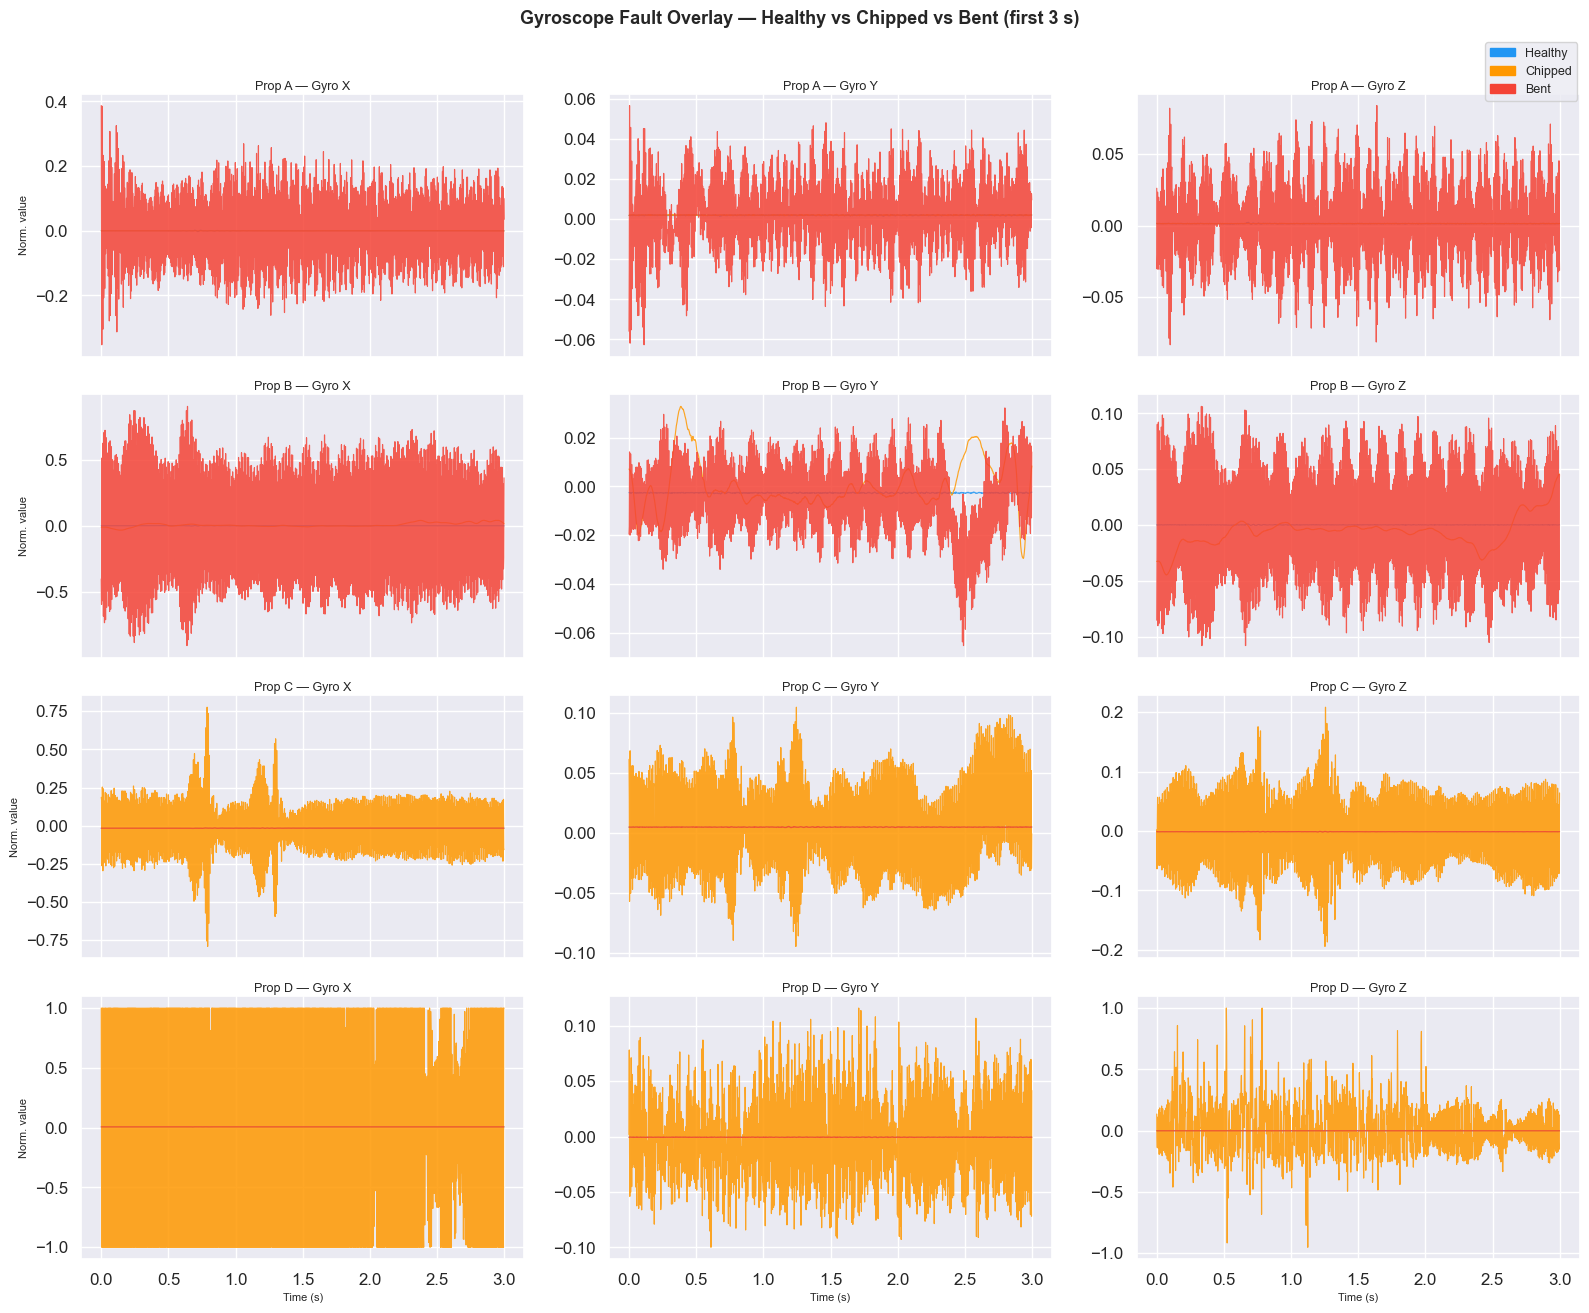

In [ ]:
fig, axes = plt.subplots(4, 3, figsize=(16, 13), sharex=True)

for r, prop in enumerate(PROPELLERS):
    file_map = SINGLE_FAULT[prop]
    for c, (col, ax_lbl) in enumerate(zip(gyro_cols(prop), AX_LABELS)):
        ax = axes[r, c]
        for fault_name, lbl in file_map.items():
            if lbl in frames:
                df_ = frames[lbl].iloc[:N_PLOT2]
                ax.plot(df_['time_s'], df_[col],
                        color=COLORS[fault_name], lw=0.85, alpha=0.85,
                        label=fault_name)
        ax.set_title(f'Prop {prop} — Gyro {ax_lbl}', fontsize=9, pad=3)
        if c == 0:
            ax.set_ylabel('Norm. value', fontsize=8)
        if r == 3:
            ax.set_xlabel('Time (s)', fontsize=8)

fig.legend(handles=legend_patches, loc='upper right', fontsize=9, bbox_to_anchor=(0.99, 0.99))
fig.suptitle('Gyroscope Fault Overlay — Healthy vs Chipped vs Bent (first 3 s)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_1_5_gyro_fault_overlay.png', bbox_inches='tight', dpi=100)
plt.show()

### §1.6 Rolling RMS — Vibration Intensity Over Full Flight

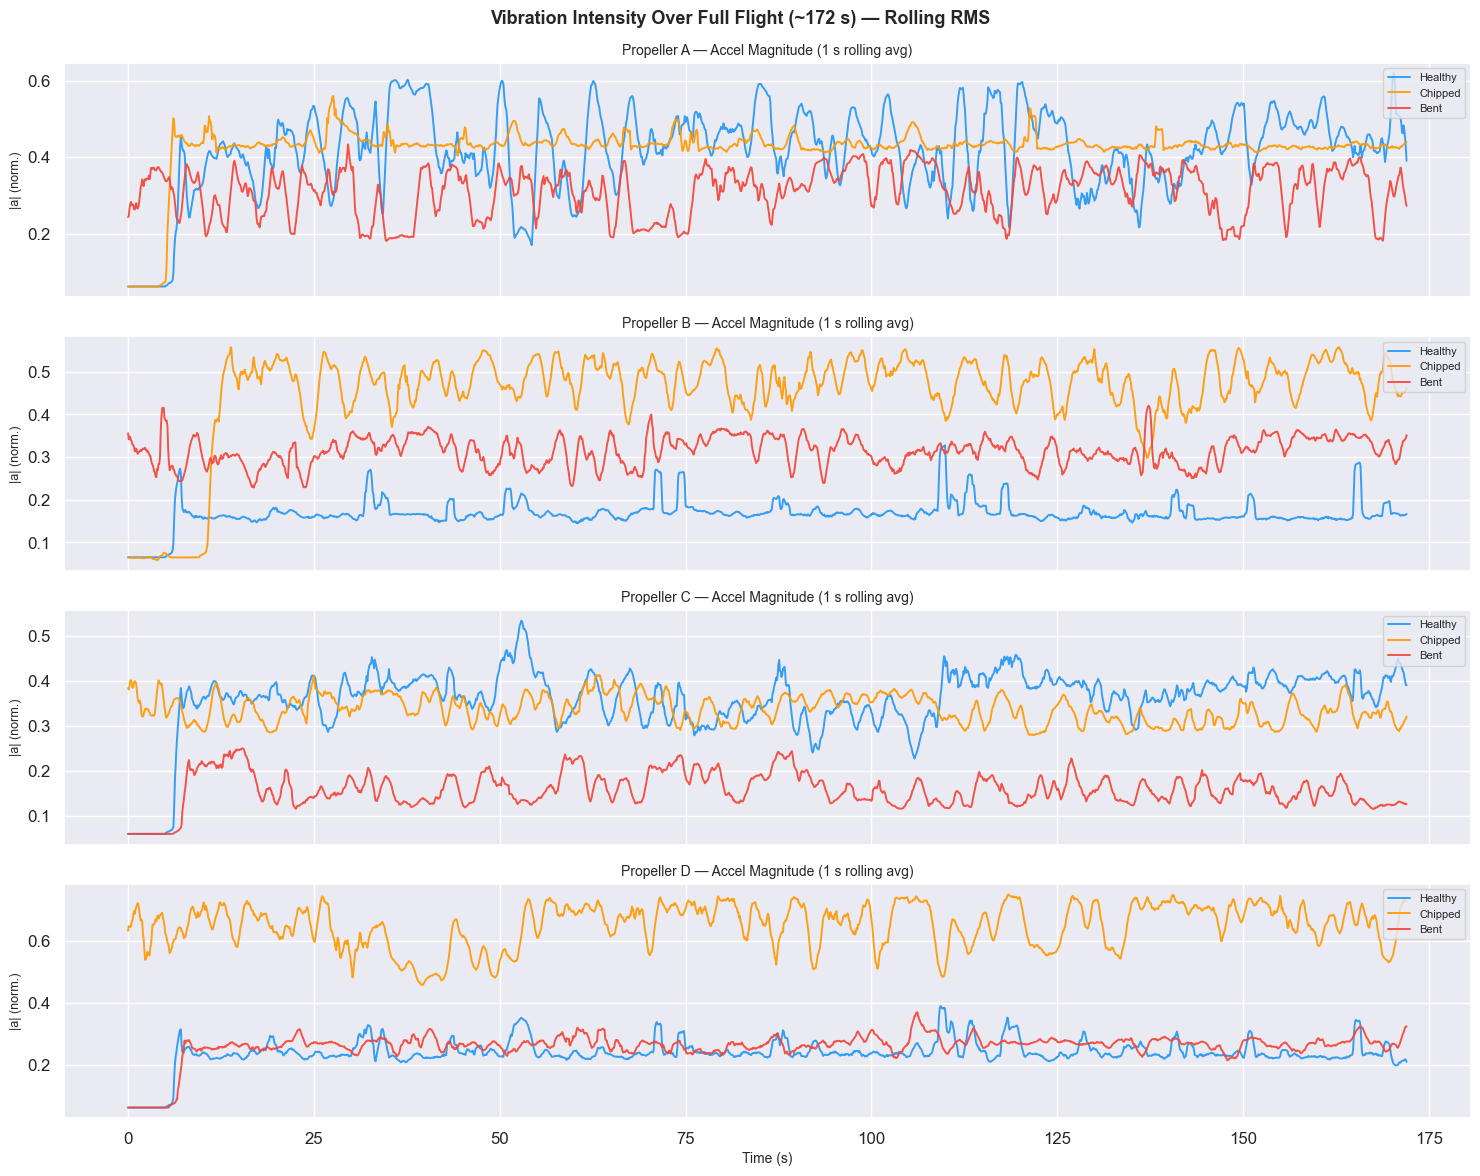

In [ ]:
ROLL_WIN    = 500
ROLL_STRIDE = 50

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

for r, prop in enumerate(PROPELLERS):
    ax       = axes[r]
    p        = prop.lower()
    file_map = SINGLE_FAULT[prop]
    for fault_name, lbl in file_map.items():
        if lbl not in frames:
            continue
        df_  = frames[lbl]
        mag  = np.sqrt(
            df_[f'{p}_ax']**2 + df_[f'{p}_ay']**2 + df_[f'{p}_az']**2
        )
        smoothed = mag.rolling(ROLL_WIN, center=True, min_periods=1).mean()
        t_ds     = df_['time_s'].values[::ROLL_STRIDE]
        y_ds     = smoothed.values[::ROLL_STRIDE]
        ax.plot(t_ds, y_ds, color=COLORS[fault_name], lw=1.4,
                label=fault_name, alpha=0.9)
    ax.set_title(f'Propeller {prop} — Accel Magnitude (1 s rolling avg)', fontsize=10)
    ax.set_ylabel('|a| (norm.)', fontsize=9)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (s)', fontsize=10)
fig.suptitle('Vibration Intensity Over Full Flight (~172 s) — Rolling RMS',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_1_6_rolling_rms.png', bbox_inches='tight', dpi=100)
plt.show()

## Part 2 — Signal Pre-processing & Feature Extraction

### §2.1 Bandpass Filtering

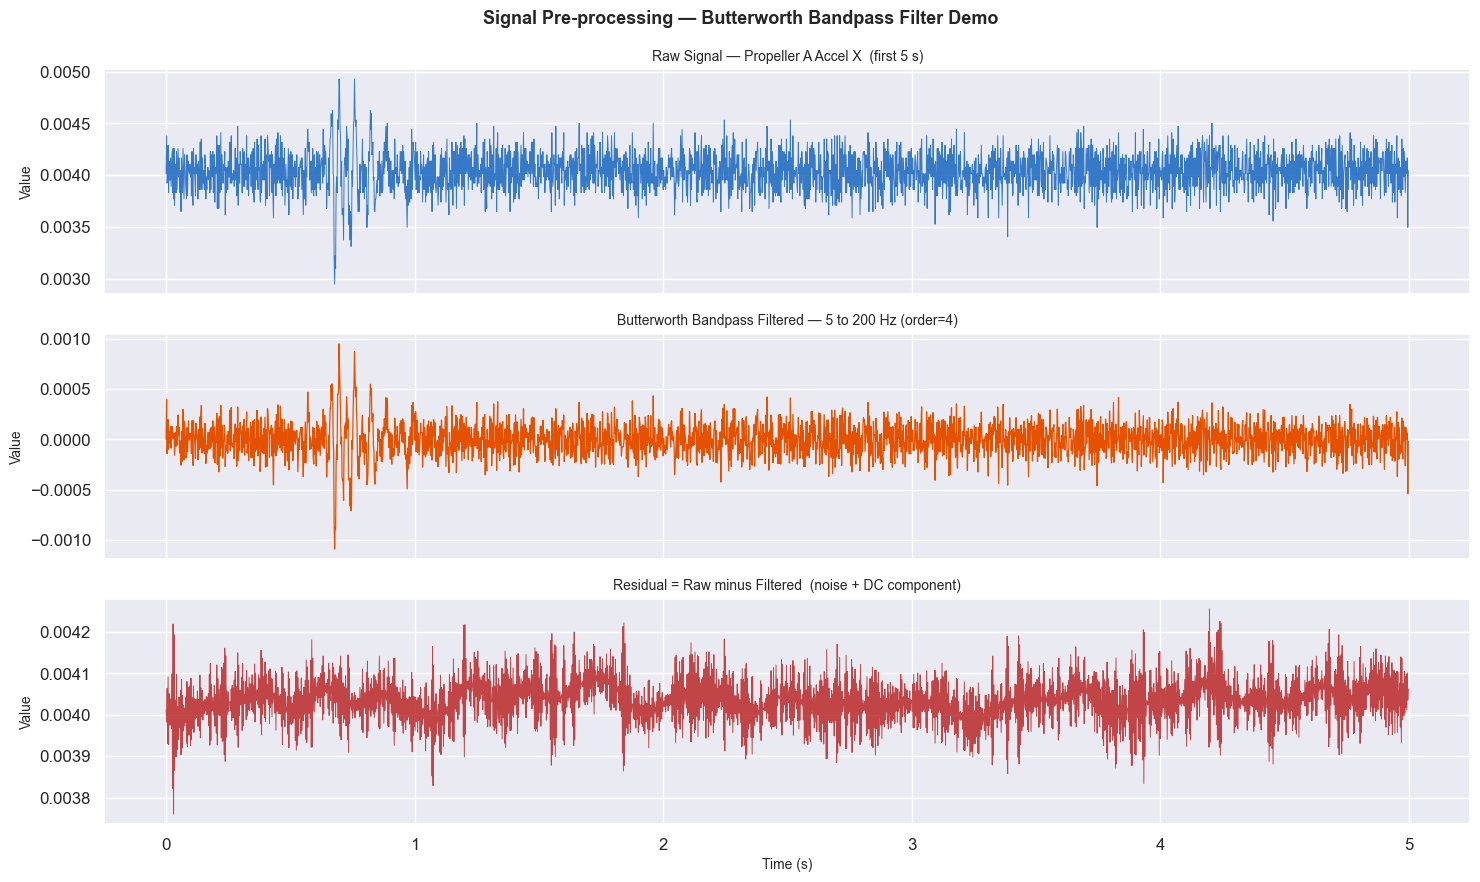

In [ ]:
nyq          = SAMPLE_RATE / 2.0
b_filt, a_filt = sp_signal.butter(4, [5 / nyq, 200 / nyq], btype='band')

prop_demo = 'A'
col_demo  = f'{prop_demo.lower()}_ax'
raw_sig   = frames['0000'][col_demo].values[:2500]
filt_sig  = sp_signal.filtfilt(b_filt, a_filt, raw_sig)
t_demo    = frames['0000']['time_s'].values[:2500]

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

axes[0].plot(t_demo, raw_sig, color='#1565C0', lw=0.7, alpha=0.85)
axes[0].set_title(f'Raw Signal — Propeller {prop_demo} Accel X  (first 5 s)', fontsize=10)
axes[0].set_ylabel('Value')

axes[1].plot(t_demo, filt_sig, color='#E65100', lw=0.9)
axes[1].set_title('Butterworth Bandpass Filtered — 5 to 200 Hz (order=4)', fontsize=10)
axes[1].set_ylabel('Value')

axes[2].plot(t_demo, raw_sig - filt_sig, color='#B71C1C', lw=0.7, alpha=0.8)
axes[2].set_title('Residual = Raw minus Filtered  (noise + DC component)', fontsize=10)
axes[2].set_ylabel('Value')
axes[2].set_xlabel('Time (s)')

fig.suptitle('Signal Pre-processing — Butterworth Bandpass Filter Demo',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_2_1_bandpass.png', bbox_inches='tight', dpi=100)
plt.show()

### §2.2 Windowed Feature Extraction

Segment every file into non-overlapping 500-sample (1 s) windows.  
Extract 10 statistical features × 6 channels × 4 propellers = **240 features per window**.

In [ ]:
def zero_crossing_rate(x):
    return float(np.sum(x[:-1] * x[1:] < 0)) / max(len(x) - 1, 1)

def extract_window_features(window_df, prop):
    feats = {}
    for col in imu_cols(prop):
        x = window_df[col].values
        std_x = np.std(x)
        feats[f'{col}_mean']   = np.mean(x)
        feats[f'{col}_std']    = std_x
        feats[f'{col}_min']    = np.min(x)
        feats[f'{col}_max']    = np.max(x)
        feats[f'{col}_ptp']    = np.ptp(x)
        feats[f'{col}_rms']    = np.sqrt(np.mean(x**2))
        feats[f'{col}_skew']   = float(sp_skew(x))    if std_x > 1e-10 else 0.0
        feats[f'{col}_kurt']   = float(sp_kurtosis(x)) if std_x > 1e-10 else 0.0
        feats[f'{col}_energy'] = float(np.sum(x**2)) / len(x)
        feats[f'{col}_zcr']    = zero_crossing_rate(x)
    return feats

def get_prop_feat_cols(df, prop):
    return [c for c in df.columns
            if any(c.startswith(f'{base_col}_') for base_col in imu_cols(prop))]

print('Extracting features from all files ...')
feat_rows = []
for lbl, df in sorted(frames.items()):
    n_win = len(df) // WINDOW_SIZE
    for w in range(n_win):
        chunk = df.iloc[w * WINDOW_SIZE : (w + 1) * WINDOW_SIZE]
        row   = {'label': lbl, 'window_idx': w}
        for idx, prop in enumerate(PROPELLERS):
            row[f'{prop}_fault'] = int(lbl[idx])
            row.update(extract_window_features(chunk, prop))
        feat_rows.append(row)

features_df = pd.DataFrame(feat_rows)
features_df.fillna(0, inplace=True)

n_meta = 2 + len(PROPELLERS)   # label + window_idx + 4 fault cols
n_feat = features_df.shape[1] - n_meta
print(f'Feature matrix: {len(features_df):,} windows x {n_feat} features')
print(f'  Per propeller: {n_feat // 4} features  (10 stats x 6 IMU channels)')
display(features_df[['label', 'window_idx', 'A_fault', 'B_fault', 'C_fault', 'D_fault']].head(4))

Extracting features from all files ...
Feature matrix: 3,440 windows x 240 features
  Per propeller: 60 features  (10 stats x 6 IMU channels)


,label,window_idx,A_fault,B_fault,C_fault,D_fault
0,0000,0,0,0,0,0
1,0000,1,0,0,0,0
2,0000,2,0,0,0,0
3,0000,3,0,0,0,0


### §2.3 Feature–Fault Correlation (Spearman)

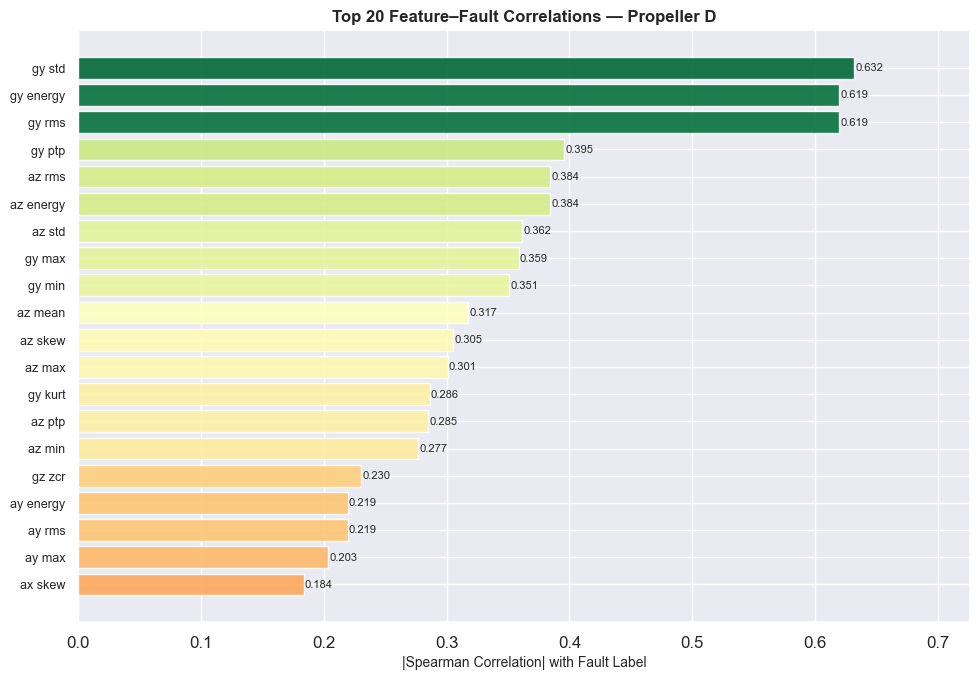

In [ ]:
prop_corr = 'D'
fault_col = f'{prop_corr}_fault'
feat_cols = get_prop_feat_cols(features_df, prop_corr)

corr_vals = {}
for fc in feat_cols:
    r, _ = spearmanr(features_df[fc], features_df[fault_col])
    corr_vals[fc] = abs(r)

top20      = sorted(corr_vals, key=corr_vals.get, reverse=True)[:20]
top_series = pd.Series({f: corr_vals[f] for f in top20}).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
cmap    = plt.cm.RdYlGn
norm_v  = top_series.values / (top_series.max() + 1e-9)
bars    = ax.barh(range(len(top_series)), top_series.values,
                  color=cmap(norm_v), alpha=0.9, edgecolor='white')
ax.set_yticks(range(len(top_series)))
ax.set_yticklabels(
    [f.replace(f'{prop_corr.lower()}_', '', 1).replace('_', ' ') for f in top_series.index],
    fontsize=9
)
ax.set_xlabel('|Spearman Correlation| with Fault Label', fontsize=10)
ax.set_title(f'Top 20 Feature–Fault Correlations — Propeller {prop_corr}',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, top_series.max() * 1.15)
for val, bar_ in zip(top_series.values, bars):
    ax.text(val + 0.001, bar_.get_y() + bar_.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(f'fig_2_3_feature_correlation_{prop_corr}.png', bbox_inches='tight', dpi=100)
plt.show()

### §2.4 Power Spectral Density

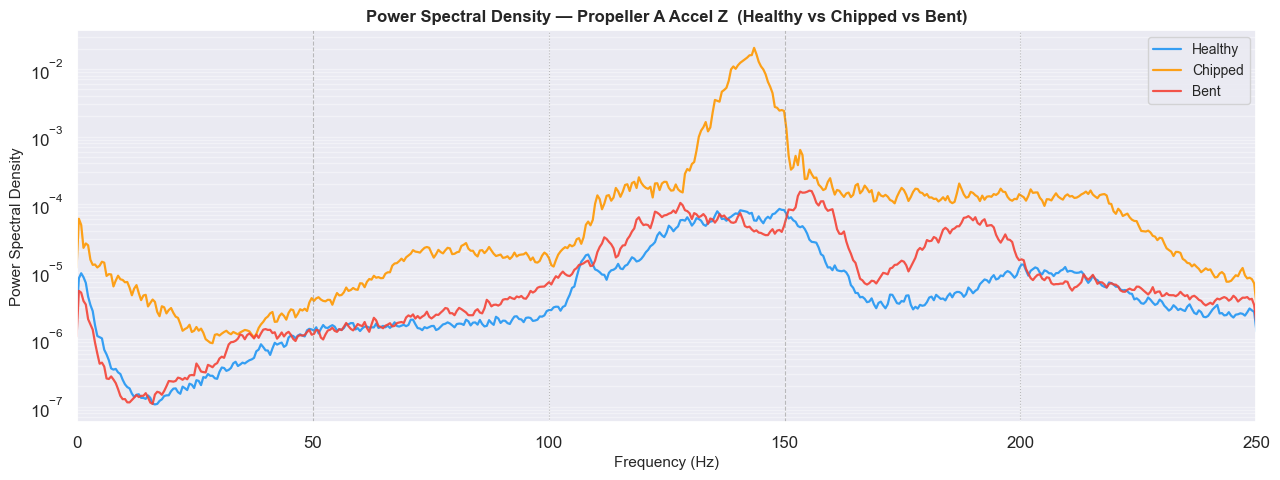

In [ ]:
col_psd = 'a_az'   # Propeller A, Accel Z

fig, ax = plt.subplots(figsize=(13, 5))

for fault_name, lbl in SINGLE_FAULT['A'].items():
    if lbl not in frames:
        continue
    sig       = frames[lbl][col_psd].values
    f_hz, Pxx = sp_signal.welch(sig, fs=SAMPLE_RATE, nperseg=1024)
    ax.semilogy(f_hz, Pxx, color=COLORS[fault_name], lw=1.6,
                label=fault_name, alpha=0.9)

ax.set_xlim(0, SAMPLE_RATE / 2)
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Power Spectral Density', fontsize=11)
ax.set_title(
    'Power Spectral Density — Propeller A Accel Z  (Healthy vs Chipped vs Bent)',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
for freq, ls in [(50, '--'), (100, ':'), (150, '--'), (200, ':')]:
    ax.axvline(x=freq, color='gray', ls=ls, lw=0.8, alpha=0.5)
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.savefig('fig_2_4_psd.png', bbox_inches='tight', dpi=100)
plt.show()

## Part 3 — Classification of Fault Conditions

### §3.1 Dataset Preparation

In [ ]:
print('Classification: predict per-propeller fault type (0=Healthy / 1=Chipped / 2=Bent')
print('ROOT CAUSE -- Why Prop D has worse accuracy:')
print('  D_Bent vs D_Healthy:    Cohen d=0.55  (62% of Bent windows overlap Healthy range)')
print('  D_Chipped vs D_Healthy: 0% overlap    (clear signal: +257% d_az, +434% d_gx)')
print('  Problem is Healthy <-> Bent confusion.')
print('  The Bent fault barely shifts D own sensors (+22% mean d_az).')
print('  Other propellers faults also bleed into D readings,')
print('  widening the Healthy class spread and eroding the boundary.')
print('FIX: use ALL 240 features (all 4 propellers) for each classifier.')
print('     Model can compare D vs A/B/C and factor out cross-propeller noise.')

# All feature columns (exclude meta columns)
meta_cols     = ['label', 'window_idx'] + [f'{p}_fault' for p in PROPELLERS]
all_feat_cols = [c for c in features_df.columns if c not in meta_cols]
print(f'Features per classifier: {len(all_feat_cols)}  (was 60 per-propeller, now {len(all_feat_cols)})')

clf_data = {}
for prop in PROPELLERS:
    fault_col  = f'{prop}_fault'
    feat_cols  = all_feat_cols
    X          = features_df[feat_cols].values.astype(float)
    y          = features_df[fault_col].values
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y
    )
    sc = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)
    clf_data[prop] = {
        'feat_cols': feat_cols, 'scaler': sc,
        'X_train': X_tr_sc, 'X_test': X_te_sc,
        'y_train': y_tr,    'y_test': y_te,
        'X_train_raw': X_tr, 'X_test_raw': X_te
    }
    counts = pd.Series(y).value_counts().sort_index()
    dist   = '  '.join(f'{FAULT_MAP[k]}={v}' for k, v in counts.items())
    print(f'  Prop {prop}: {len(X):>5} windows  |  {dist}')


Classification: predict per-propeller fault type (0=Healthy / 1=Chipped / 2=Bent
ROOT CAUSE -- Why Prop D has worse accuracy:
  D_Bent vs D_Healthy:    Cohen d=0.55  (62% of Bent windows overlap Healthy range)
  D_Chipped vs D_Healthy: 0% overlap    (clear signal: +257% d_az, +434% d_gx)
  Problem is Healthy <-> Bent confusion.
  The Bent fault barely shifts D own sensors (+22% mean d_az).
  Other propellers faults also bleed into D readings,
  widening the Healthy class spread and eroding the boundary.
FIX: use ALL 240 features (all 4 propellers) for each classifier.
     Model can compare D vs A/B/C and factor out cross-propeller noise.
Features per classifier: 240  (was 60 per-propeller, now 240)
  Prop A:  3440 windows  |  Healthy=1892  Chipped=1376  Bent=172
  Prop B:  3440 windows  |  Healthy=1892  Chipped=1376  Bent=172
  Prop C:  3440 windows  |  Healthy=1892  Chipped=172  Bent=1376
  Prop D:  3440 windows  |  Healthy=1892  Chipped=172  Bent=1376


### §3.2 Random Forest Classifier

Training Random Forest classifiers ...
  Prop A  Accuracy=0.999  Weighted-F1=0.999
  Prop B  Accuracy=0.987  Weighted-F1=0.987
  Prop C  Accuracy=0.997  Weighted-F1=0.997
  Prop D  Accuracy=0.978  Weighted-F1=0.978


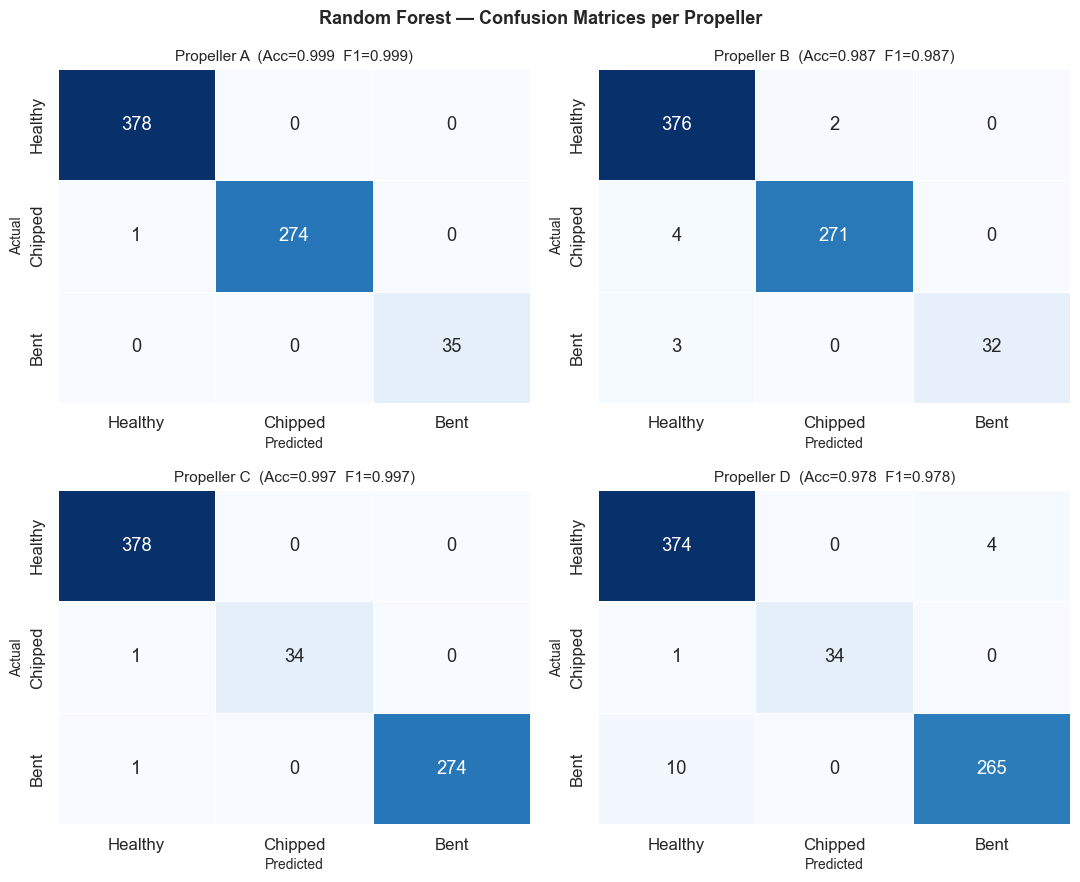

In [ ]:
rf_models  = {}
rf_results = {}

print('Training Random Forest classifiers ...')
for prop in PROPELLERS:
    d  = clf_data[prop]
    rf = RandomForestClassifier(
        n_estimators=200, class_weight='balanced',
        random_state=42, n_jobs=-1
    )
    rf.fit(d['X_train'], d['y_train'])
    y_pred = rf.predict(d['X_test'])
    acc    = accuracy_score(d['y_test'], y_pred)
    f1     = f1_score(d['y_test'], y_pred, average='weighted', zero_division=0)
    cm     = confusion_matrix(d['y_test'], y_pred, labels=[0, 1, 2])
    rf_models[prop]  = rf
    rf_results[prop] = {'acc': acc, 'f1': f1, 'cm': cm, 'y_pred': y_pred}
    print(f'  Prop {prop}  Accuracy={acc:.3f}  Weighted-F1={f1:.3f}')

# Confusion matrices
class_labels = [FAULT_MAP[k] for k in range(3)]
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, prop in zip(axes.flat, PROPELLERS):
    cm_ = rf_results[prop]['cm']
    sns.heatmap(cm_, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=0.5, cbar=False)
    ax.set_title(f'Propeller {prop}  (Acc={rf_results[prop]["acc"]:.3f}  '
                 f'F1={rf_results[prop]["f1"]:.3f})', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

fig.suptitle('Random Forest — Confusion Matrices per Propeller',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_3_2_rf_confusion.png', bbox_inches='tight', dpi=100)
plt.show()

### §3.3 SVM Classifier — Comparison

Training SVM classifiers ...
  Prop A  Accuracy=0.991  Weighted-F1=0.991
  Prop B  Accuracy=0.984  Weighted-F1=0.984
  Prop C  Accuracy=0.993  Weighted-F1=0.993
  Prop D  Accuracy=0.994  Weighted-F1=0.994


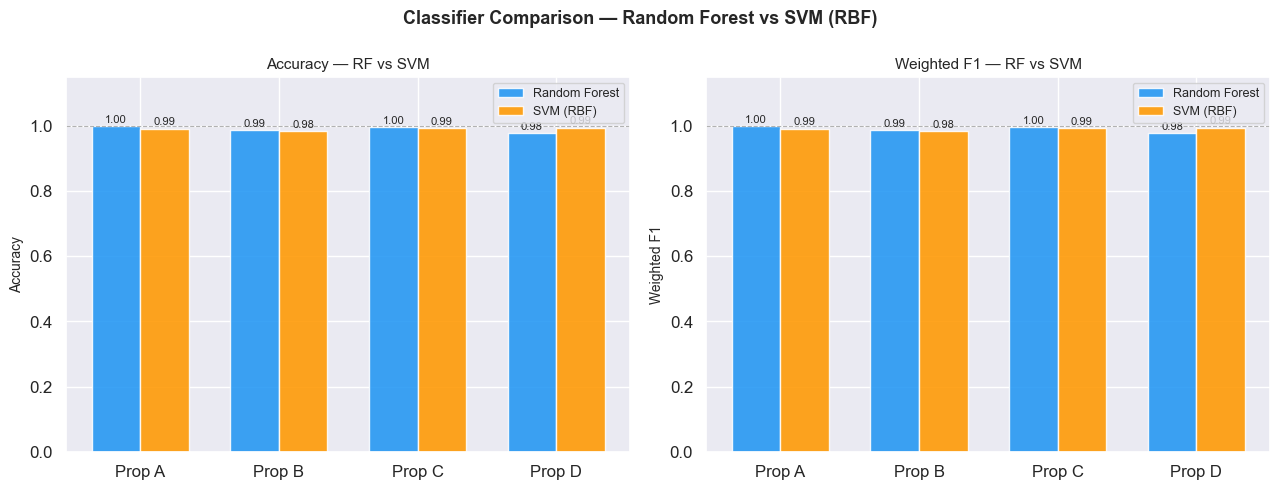

In [ ]:
svm_results = {}

print('Training SVM classifiers ...')
for prop in PROPELLERS:
    d   = clf_data[prop]
    svm = SVC(kernel='rbf', C=10, class_weight='balanced', random_state=42)
    svm.fit(d['X_train'], d['y_train'])
    y_pred = svm.predict(d['X_test'])
    acc    = accuracy_score(d['y_test'], y_pred)
    f1     = f1_score(d['y_test'], y_pred, average='weighted', zero_division=0)
    svm_results[prop] = {'acc': acc, 'f1': f1, 'y_pred': y_pred}
    print(f'  Prop {prop}  Accuracy={acc:.3f}  Weighted-F1={f1:.3f}')

# Side-by-side bar chart
x      = np.arange(len(PROPELLERS))
width  = 0.35
rf_acc  = [rf_results[p]['acc']  for p in PROPELLERS]
svm_acc = [svm_results[p]['acc'] for p in PROPELLERS]
rf_f1   = [rf_results[p]['f1']   for p in PROPELLERS]
svm_f1  = [svm_results[p]['f1']  for p in PROPELLERS]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric_name, rf_vals, svm_vals in [
    (axes[0], 'Accuracy',    rf_acc,  svm_acc),
    (axes[1], 'Weighted F1', rf_f1,   svm_f1)
]:
    ax.bar(x - width/2, rf_vals,  width, label='Random Forest', color='#2196F3', alpha=0.88)
    ax.bar(x + width/2, svm_vals, width, label='SVM (RBF)',     color='#FF9800', alpha=0.88)
    for xi, (rv, sv) in enumerate(zip(rf_vals, svm_vals)):
        ax.text(xi - width/2, rv  + 0.01, f'{rv:.2f}',  ha='center', fontsize=8)
        ax.text(xi + width/2, sv  + 0.01, f'{sv:.2f}',  ha='center', fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels([f'Prop {p}' for p in PROPELLERS])
    ax.set_ylabel(metric_name)
    ax.set_ylim(0, 1.15)
    ax.set_title(f'{metric_name} — RF vs SVM', fontsize=11)
    ax.legend()
    ax.axhline(1.0, color='gray', ls='--', lw=0.8, alpha=0.6)

fig.suptitle('Classifier Comparison — Random Forest vs SVM (RBF)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_3_3_classifier_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

### §3.4 Feature Importances — RF Propeller D (all 240 features)

Showing **Propeller D** (the low-accuracy case). Features are coloured by which propeller's sensors they come from, revealing how much cross-propeller context the model relies on.

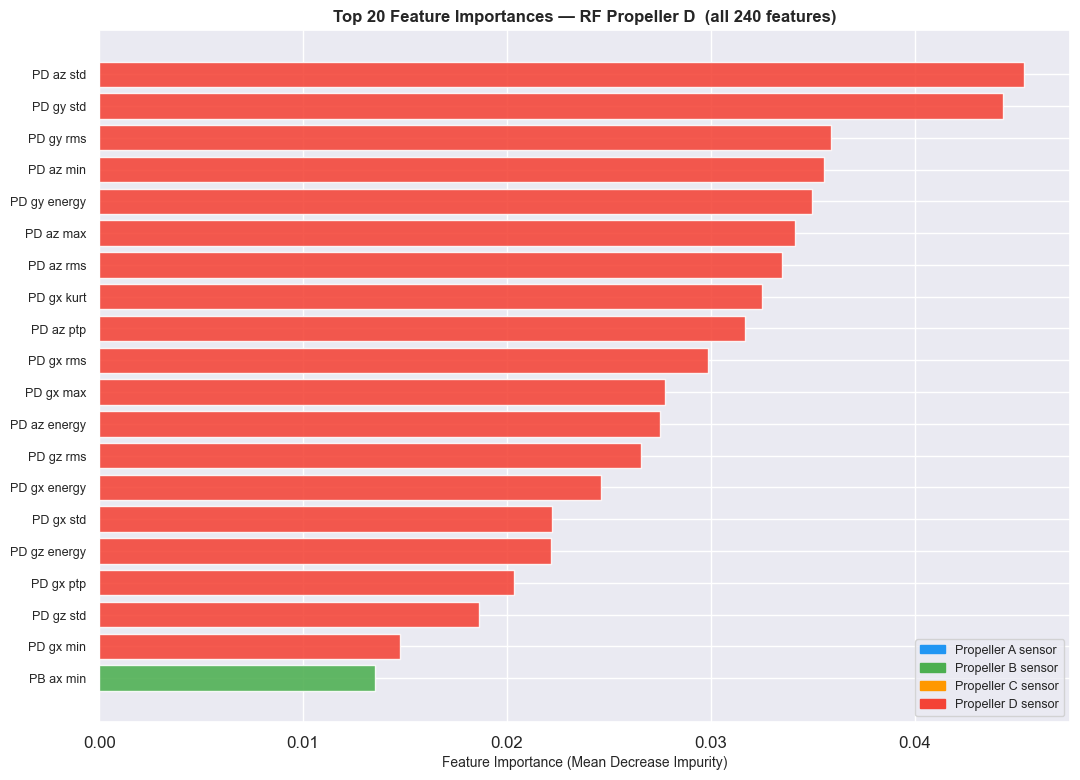

 Cross-propeller feature importance share for Prop D classifier:
  Propeller A features: 6.3% of total importance
  Propeller B features: 13.0% of total importance
  Propeller C features: 7.9% of total importance
  Propeller D features: 72.8% of total importance


In [ ]:
# Show D — the problem propeller — to visualise which sensors help most
prop_fi   = 'D'
rf_fi     = rf_models[prop_fi]
feat_list = clf_data[prop_fi]['feat_cols']
imps      = rf_fi.feature_importances_

top_n    = 20
idx_sort = np.argsort(imps)[-top_n:]
top_names = [feat_list[i] for i in idx_sort]
top_imps  = imps[idx_sort]

# Color by which propeller owns the feature
prop_colors = {'a': '#2196F3', 'b': '#4CAF50', 'c': '#FF9800', 'd': '#F44336'}

def feat_owner_color(name):
    owner = name[0].lower()
    return prop_colors.get(owner, '#9C27B0')

def shorten(name):
    parts = name.split('_')   # ['a', 'ax', 'rms'] or ['a', 'ax', 'mean'] etc.
    return f'P{parts[0].upper()} {parts[1]} {parts[-1]}'

bar_colors = [feat_owner_color(n) for n in top_names]

fig, ax = plt.subplots(figsize=(11, 8))
ax.barh(range(top_n), top_imps, color=bar_colors, alpha=0.88, edgecolor='white')
ax.set_yticks(range(top_n))
ax.set_yticklabels([shorten(n) for n in top_names], fontsize=9)
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)', fontsize=10)
ax.set_title(f'Top {top_n} Feature Importances — RF Propeller {prop_fi}  (all 240 features)',
             fontsize=12, fontweight='bold')

legend_els = [
    mpatches.Patch(color=prop_colors[p.lower()], label=f'Propeller {p} sensor')
    for p in PROPELLERS
]
ax.legend(handles=legend_els, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(f'fig_3_4_feature_importance_{prop_fi}.png', bbox_inches='tight', dpi=100)
plt.show()

print(f' Cross-propeller feature importance share for Prop {prop_fi} classifier:')
for p in PROPELLERS:
    mask  = np.array([n.startswith(p.lower() + '_') for n in feat_list])
    share = imps[mask].sum() * 100
    print(f'  Propeller {p} features: {share:.1f}% of total importance')


### §3.5 Classification Reports

In [ ]:
print('CLASSIFICATION REPORTS — Random Forest  (test set)\n')
print('=' * 60)
for prop in PROPELLERS:
    d      = clf_data[prop]
    y_pred = rf_results[prop]['y_pred']
    print(f'\nPropeller {prop}')
    print('-' * 45)
    print(classification_report(
        d['y_test'], y_pred,
        target_names=[FAULT_MAP[k] for k in range(3)],
        zero_division=0
    ))

CLASSIFICATION REPORTS — Random Forest  (test set)


Propeller A
---------------------------------------------
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       378
     Chipped       1.00      1.00      1.00       275
        Bent       1.00      1.00      1.00        35

    accuracy                           1.00       688
   macro avg       1.00      1.00      1.00       688
weighted avg       1.00      1.00      1.00       688


Propeller B
---------------------------------------------
              precision    recall  f1-score   support

     Healthy       0.98      0.99      0.99       378
     Chipped       0.99      0.99      0.99       275
        Bent       1.00      0.91      0.96        35

    accuracy                           0.99       688
   macro avg       0.99      0.96      0.98       688
weighted avg       0.99      0.99      0.99       688


Propeller C
---------------------------------------------
         

## Part 4 — Anomaly Detection & Sensor Fault Prediction

### §4.1 Isolation Forest — Unsupervised Fault Detection

Training Isolation Forest on healthy windows only ...
  Prop A  healthy anomaly score=0.4119  faulty=0.6063
  Prop B  healthy anomaly score=0.4213  faulty=0.5279
  Prop C  healthy anomaly score=0.4136  faulty=0.5312
  Prop D  healthy anomaly score=0.4195  faulty=0.4723


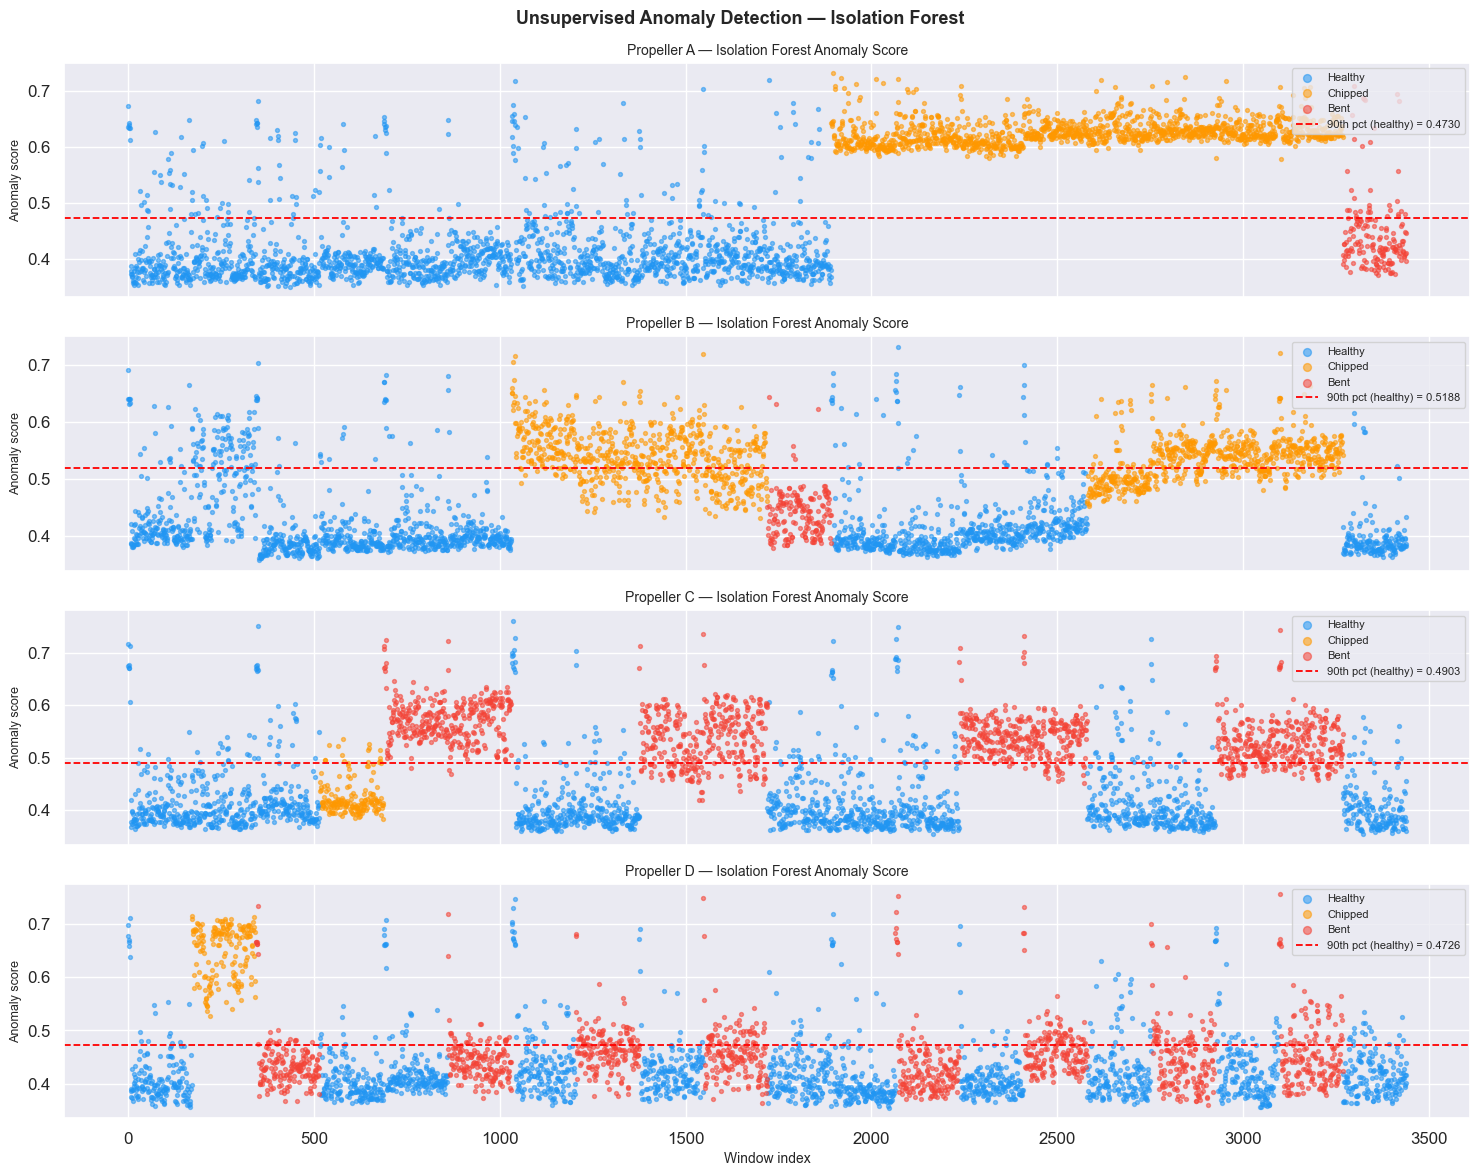

In [ ]:
if_models     = {}
if_scores_all = {}

print('Training Isolation Forest on healthy windows only ...')
for prop in PROPELLERS:
    feat_cols    = get_prop_feat_cols(features_df, prop)
    fault_col    = f'{prop}_fault'
    healthy_mask = (features_df[fault_col] == 0).values
    X_all        = features_df[feat_cols].values.astype(float)
    X_healthy    = X_all[healthy_mask]

    sc_if        = StandardScaler().fit(X_healthy)
    X_healthy_sc = sc_if.transform(X_healthy)
    X_all_sc     = sc_if.transform(X_all)

    iso_f = IsolationForest(contamination=0.1, random_state=42, n_jobs=-1)
    iso_f.fit(X_healthy_sc)

    scores = -iso_f.score_samples(X_all_sc)   # higher = more anomalous
    if_models[prop]     = (iso_f, sc_if)
    if_scores_all[prop] = scores

    h_mean = scores[healthy_mask].mean()
    f_mean = scores[~healthy_mask].mean()
    print(f'  Prop {prop}  healthy anomaly score={h_mean:.4f}  faulty={f_mean:.4f}')

# Plot anomaly scores
fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

for r, prop in enumerate(PROPELLERS):
    ax        = axes[r]
    fault_col = f'{prop}_fault'
    scores_p  = if_scores_all[prop]
    fault_arr = features_df[fault_col].values

    for fault_int, fault_name in FAULT_MAP.items():
        mask = fault_arr == fault_int
        if not mask.any():
            continue
        w_idx = np.where(mask)[0]
        ax.scatter(w_idx, scores_p[mask],
                   c=COLORS[fault_name], s=8, alpha=0.55, label=fault_name)

    thresh = np.percentile(scores_p[fault_arr == 0], 90)
    ax.axhline(thresh, color='red', ls='--', lw=1.3,
               label=f'90th pct (healthy) = {thresh:.4f}')
    ax.set_title(f'Propeller {prop} — Isolation Forest Anomaly Score', fontsize=10)
    ax.set_ylabel('Anomaly score', fontsize=9)
    ax.legend(loc='upper right', fontsize=8, markerscale=2)

axes[-1].set_xlabel('Window index', fontsize=10)
fig.suptitle('Unsupervised Anomaly Detection — Isolation Forest',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_4_1_isolation_forest.png', bbox_inches='tight', dpi=100)
plt.show()

### §4.2 Z-Score Anomaly Detection

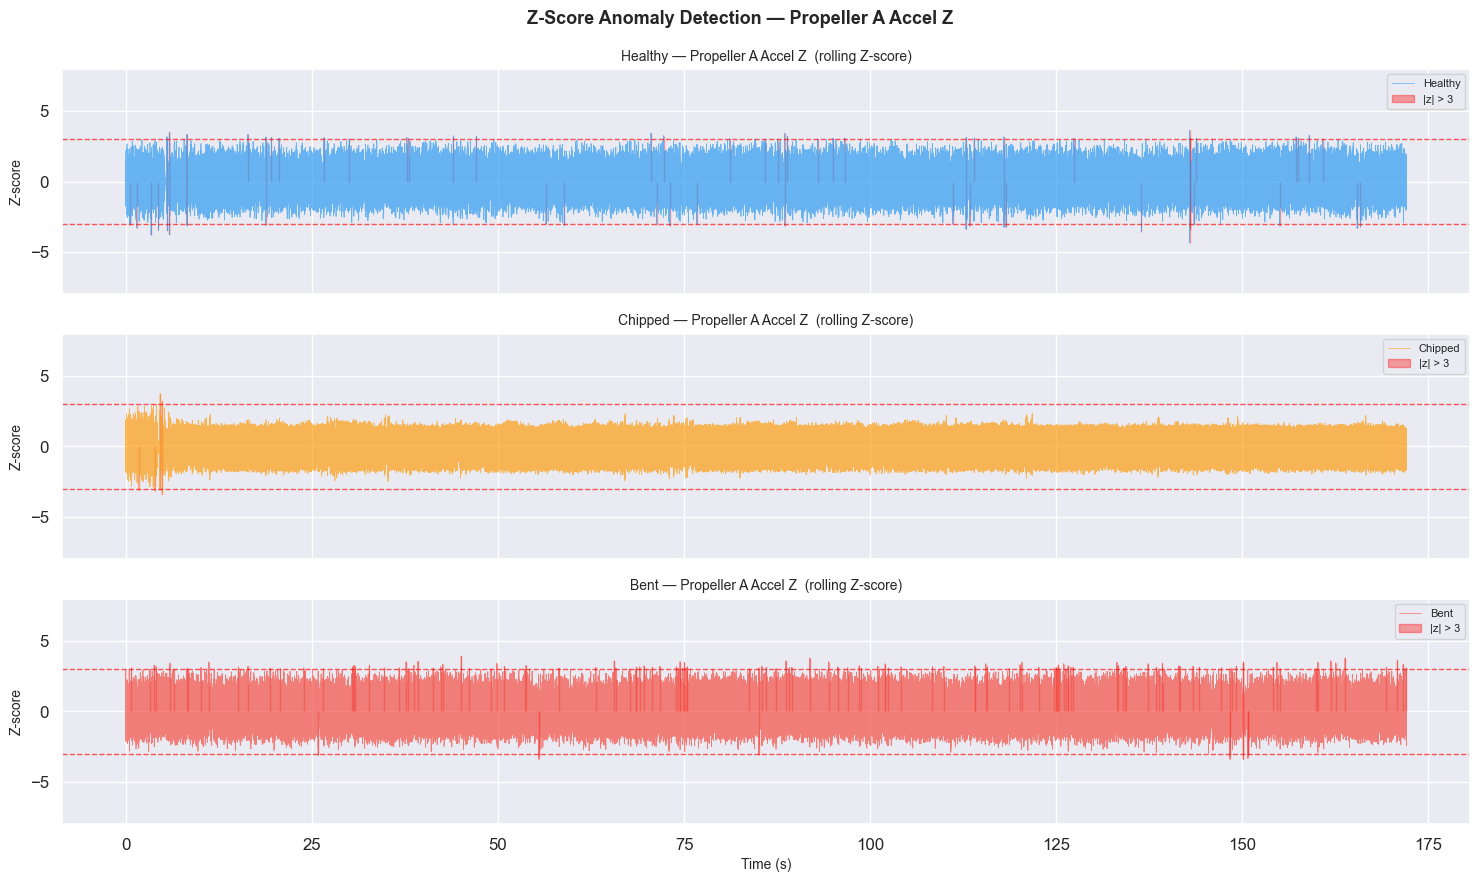

In [ ]:
ROLL_Z   = 200   # rolling window for local mean/std
prop_z   = 'A'
col_z    = f'{prop_z.lower()}_az'
files_z  = SINGLE_FAULT[prop_z]

fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)

for ax, (fault_name, lbl) in zip(axes, files_z.items()):
    if lbl not in frames:
        ax.set_visible(False)
        continue
    sig  = frames[lbl][col_z]
    mu   = sig.rolling(ROLL_Z, center=True, min_periods=1).mean()
    std_ = sig.rolling(ROLL_Z, center=True, min_periods=1).std().fillna(1e-9).replace(0, 1e-9)
    z    = (sig - mu) / std_
    t    = frames[lbl]['time_s']

    ax.plot(t, z, color=COLORS[fault_name], lw=0.55, alpha=0.65, label=fault_name)
    spike = (z > 3) | (z < -3)
    ax.fill_between(t, z.clip(-8, 8), where=spike,
                    color='red', alpha=0.35, label='|z| > 3')
    ax.axhline( 3, color='red', ls='--', lw=1.0, alpha=0.65)
    ax.axhline(-3, color='red', ls='--', lw=1.0, alpha=0.65)
    ax.set_title(f'{fault_name} — Propeller {prop_z} Accel Z  (rolling Z-score)', fontsize=10)
    ax.set_ylabel('Z-score')
    ax.set_ylim(-8, 8)
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (s)', fontsize=10)
fig.suptitle('Z-Score Anomaly Detection — Propeller A Accel Z',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_4_2_zscore.png', bbox_inches='tight', dpi=100)
plt.show()

### §4.3 Reconstruction Error — Statistical Baseline

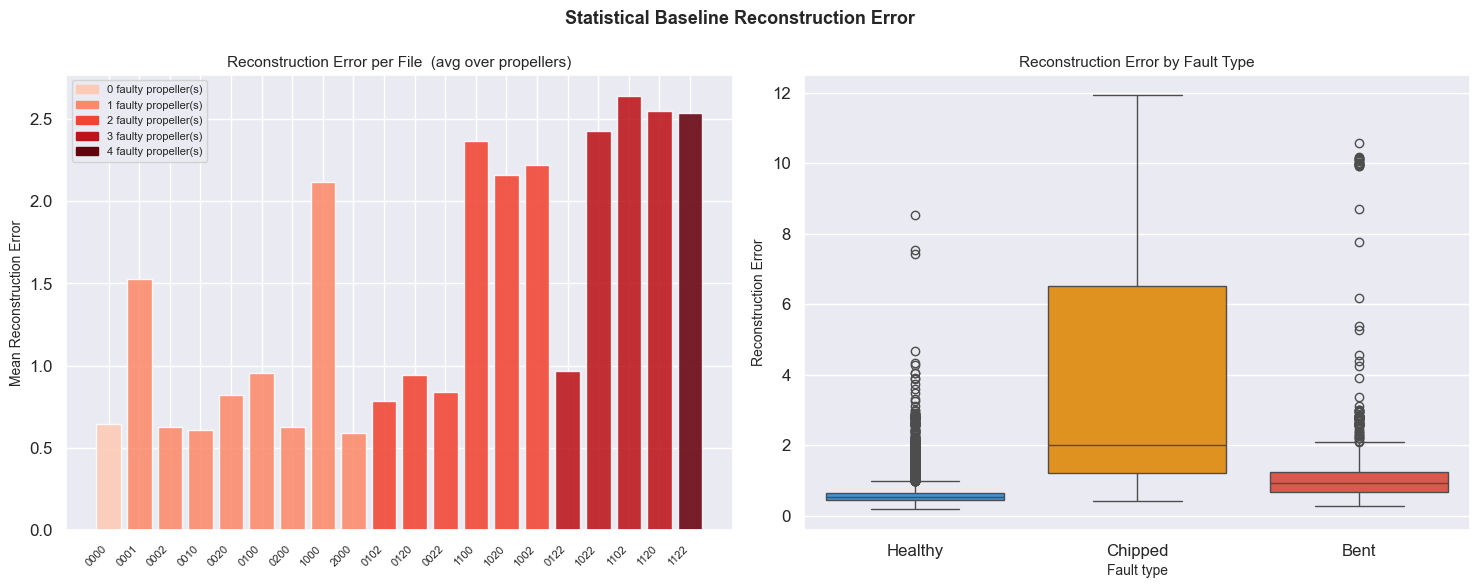

In [ ]:
recon_parts = []

for prop in PROPELLERS:
    feat_cols    = get_prop_feat_cols(features_df, prop)
    fault_col    = f'{prop}_fault'
    healthy_mask = (features_df[fault_col] == 0).values
    X_all        = features_df[feat_cols].values.astype(float)
    X_healthy    = X_all[healthy_mask]

    mu_h  = X_healthy.mean(axis=0)
    std_h = X_healthy.std(axis=0) + 1e-9
    err   = np.mean(np.abs((X_all - mu_h) / std_h), axis=1)

    tmp              = features_df[['label', fault_col]].copy()
    tmp['error']     = err
    tmp['prop']      = prop
    tmp['fault_name']= tmp[fault_col].map(FAULT_MAP)
    tmp['n_faults']  = tmp['label'].apply(lambda l: sum(int(d) > 0 for d in l))
    tmp = tmp.rename(columns={fault_col: 'fault'})
    recon_parts.append(tmp[['label', 'prop', 'fault', 'fault_name', 'error', 'n_faults']])

recon_df = pd.concat(recon_parts, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left — mean error per file (avg over propellers), coloured by #faults
file_mean = (recon_df
             .groupby(['label', 'n_faults'])['error']
             .mean().reset_index()
             .sort_values('n_faults'))
cmap_n    = plt.cm.Reds
nfault_vals = sorted(file_mean['n_faults'].unique())
pal       = {n: cmap_n(0.2 + 0.2 * n) for n in nfault_vals}
bar_cols  = [pal[n] for n in file_mean['n_faults']]
axes[0].bar(range(len(file_mean)), file_mean['error'],
            color=bar_cols, alpha=0.88, edgecolor='white')
axes[0].set_xticks(range(len(file_mean)))
axes[0].set_xticklabels(file_mean['label'], rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Mean Reconstruction Error')
axes[0].set_title('Reconstruction Error per File  (avg over propellers)', fontsize=11)
axes[0].legend(
    handles=[mpatches.Patch(color=pal[n], label=f'{n} faulty propeller(s)') for n in nfault_vals],
    fontsize=8, loc='upper left'
)

# Right — box plot by fault type
sns.boxplot(
    data=recon_df, x='fault_name', y='error',
    order=['Healthy', 'Chipped', 'Bent'],
    palette=COLORS, ax=axes[1], linewidth=1.0
)
axes[1].set_xlabel('Fault type')
axes[1].set_ylabel('Reconstruction Error')
axes[1].set_title('Reconstruction Error by Fault Type', fontsize=11)

fig.suptitle('Statistical Baseline Reconstruction Error',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_4_3_reconstruction_error.png', bbox_inches='tight', dpi=100)
plt.show()

### §4.4 ROC Curves — Fault Detection Performance

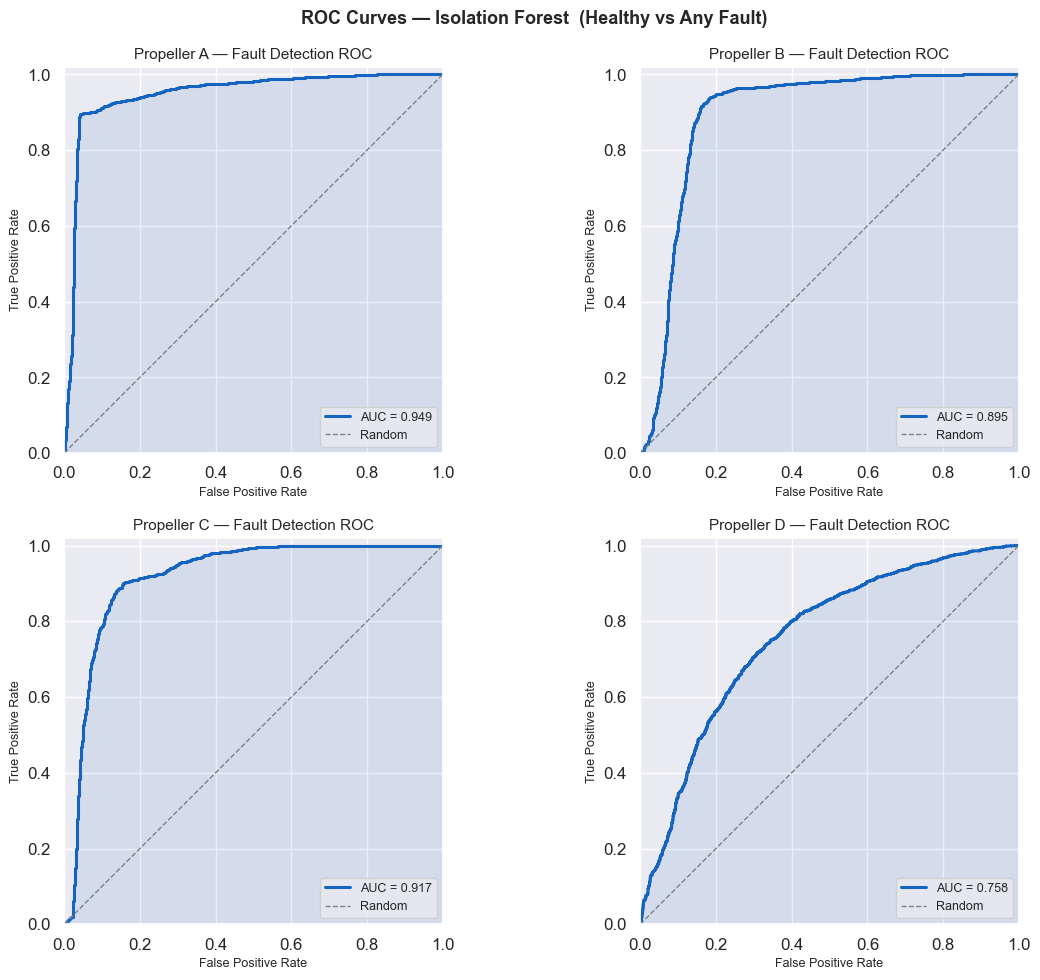


Summary of AUC scores:
  Prop A: AUC = 0.9494
  Prop B: AUC = 0.8945
  Prop C: AUC = 0.9173
  Prop D: AUC = 0.7577


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, prop in zip(axes.flat, PROPELLERS):
    fault_col = f'{prop}_fault'
    y_binary  = (features_df[fault_col].values > 0).astype(int)
    scores_p  = if_scores_all[prop]

    if y_binary.sum() == 0 or (1 - y_binary).sum() == 0:
        ax.text(0.5, 0.5, 'Single class — ROC undefined',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Propeller {prop}', fontsize=11)
        continue

    fpr, tpr, _ = roc_curve(y_binary, scores_p)
    roc_auc     = auc(fpr, tpr)

    ax.plot(fpr, tpr, color='#1565C0', lw=2.2,
            label=f'AUC = {roc_auc:.3f}')
    ax.fill_between(fpr, tpr, alpha=0.10, color='#1565C0')
    ax.plot([0, 1], [0, 1], color='gray', lw=1.0, ls='--', label='Random')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate', fontsize=9)
    ax.set_title(f'Propeller {prop} — Fault Detection ROC', fontsize=11)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_aspect('equal')

fig.suptitle(
    'ROC Curves — Isolation Forest  (Healthy vs Any Fault)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig_4_4_roc_curves.png', bbox_inches='tight', dpi=100)
plt.show()

print('\nSummary of AUC scores:')
for prop in PROPELLERS:
    fault_col = f'{prop}_fault'
    y_bin     = (features_df[fault_col].values > 0).astype(int)
    if y_bin.sum() == 0 or (1-y_bin).sum() == 0:
        print(f'  Prop {prop}: N/A (single class)')
        continue
    fpr_, tpr_, _ = roc_curve(y_bin, if_scores_all[prop])
    print(f'  Prop {prop}: AUC = {auc(fpr_, tpr_):.4f}')